# Long Read Inversion Assessment
Here, we visualize the inversions that were identified across all size, depth, and platform treatments for long reads.

In [ ]:
library(ggplot2)
library(dplyr)
library(ggpubr)
options(warn = -1, repr.plot.width = 19, repr.plot.height = 12)


Attaching package: 'dplyr'


The following objects are masked from 'package:stats':

    filter, lag


The following objects are masked from 'package:base':

    intersect, setdiff, setequal, union




Read in the aggregate inversion discovery manifest

In [3]:
found_inversions <- read.table("longread.inversions.summary", header = T)
nrow(found_inversions)
head(found_inversions)

[1] 3751

,sample,size,depth,platform,chrom,start,end,quality
,<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<chr>
1,sample_01,small,0.5,pacbio,2L,3193195,3214220,LowQual
2,sample_01,small,0.5,ontshort,2L,20107900,20113694,LowQual
3,sample_01,small,5.0,pacbio,2L,3193195,3214220,PASS
4,sample_01,small,5.0,pacbio,2L,3193197,3214220,PASS
5,sample_01,small,5.0,pacbio,2L,3940210,3944862,PASS
6,sample_01,small,5.0,pacbio,2L,3940211,3944863,PASS


There are approximate duplicates in here, so we need to filter out rows with breakpoints that are within a few bp of each other

In [19]:
remove_nearby_duplicates <- function(df, threshold = 20) {
  n <- nrow(df)
  if (n <= 1) return(df)
  # Sort by start position within each group for efficiency
  df <- df[order(df$start), ]
  keep <- rep(TRUE, n)
  for (i in 1:(n-1)) {
    if (!keep[i]) next
    # Only check rows that could potentially be within threshold
    remaining_idx <- (i+1):n
    start_diffs <- abs(df$start[i] - df$start[remaining_idx])

    # Early exit if start positions are already too far apart (since sorted)
    if (min(start_diffs) > threshold) break

    end_diffs <- abs(df$end[i] - df$end[remaining_idx])

    # Mark rows that are too close
    too_close <- which(start_diffs <= threshold & end_diffs <= threshold)
    if (length(too_close) > 0) {
      keep[remaining_idx[too_close]] <- FALSE
    }
  }

  return(df[keep, ])
}


In [ ]:
cleaned_inversions <- found_inversions %>%
  group_by(sample, chrom, size, depth, platform) %>%
  group_modify(~ remove_nearby_duplicates(.x, threshold = 20)) %>%
  ungroup()
nrow(cleaned_inversions)
head(cleaned_inversions, 10)

[1] 2289

sample,chrom,size,depth,platform,start,end,quality
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
sample_01,2L,large,5,ontlong,11529164,15060029,PASS
sample_01,2L,large,5,ontlong,18872128,20461265,PASS
sample_01,2L,large,5,ontshort,11529164,15060029,PASS
sample_01,2L,large,5,ontshort,18872128,20461265,PASS
sample_01,2L,large,5,pacbio,11529164,15060029,PASS
sample_01,2L,large,5,pacbio,18872128,20461265,PASS
sample_01,2L,large,20,ontlong,11529164,15060029,PASS
sample_01,2L,large,20,ontlong,18872128,20461265,PASS
sample_01,2L,large,20,ontshort,11529164,15060029,PASS


Small sanity check to make sure the deduplication was accurate

In [ ]:
filter(found_inversions,   platform == "pacbio", chrom == "2L", size == "small", sample == "sample_01", depth == 5)
filter(cleaned_inversions, platform == "pacbio", chrom == "2L", size == "small",  sample == "sample_01", depth == 5)

sample,chrom,size,depth,platform,start,end,quality
<chr>,<chr>,<chr>,<dbl>,<chr>,<int>,<int>,<chr>
sample_01,2L,small,5,pacbio,3193195,3214220,PASS
sample_01,2L,small,5,pacbio,3940210,3944862,PASS
sample_01,2L,small,5,pacbio,13024403,13026576,PASS
sample_01,2L,small,5,pacbio,14845708,14861199,LowQual
sample_01,2L,small,5,pacbio,20107900,20113694,PASS


sample,size,depth,platform,chrom,start,end,quality
<chr>,<chr>,<dbl>,<chr>,<chr>,<int>,<int>,<chr>
sample_01,small,5,pacbio,2L,3193195,3214220,PASS
sample_01,small,5,pacbio,2L,3193197,3214220,PASS
sample_01,small,5,pacbio,2L,3940210,3944862,PASS
sample_01,small,5,pacbio,2L,3940211,3944863,PASS
sample_01,small,5,pacbio,2L,13024403,13026576,PASS
sample_01,small,5,pacbio,2L,13024405,13026576,LowQual
sample_01,small,5,pacbio,2L,14845708,14861199,LowQual
sample_01,small,5,pacbio,2L,14845710,14861199,PASS
sample_01,small,5,pacbio,2L,20107900,20113694,PASS


Read in the groundtruth file

In [18]:
groundtruth <- read.table("manifest.breakpoints", header = T)
head(groundtruth)

,sample,contig,position_start,position_end,size,present,state
,<chr>,<chr>,<int>,<int>,<chr>,<lgl>,<chr>
1,sample_01,2L,11529165,15060030,large,TRUE,hom
2,sample_08,2L,11529165,15060030,large,TRUE,hom
3,sample_02,2L,11529165,15060030,large,TRUE,hom
4,sample_09,2L,11529165,15060030,large,TRUE,hom
5,sample_03,2L,11529165,15060030,large,TRUE,hom
6,sample_10,2L,11529165,15060030,large,TRUE,hom


To avoid merging the breakpoints with the samples-inversions manifest each time, this process was done once with the code below and written to the file imported above.

In [ ]:
# Get all the inversion breakpoints
groundtruth <- read.table("../inversion_simulations.inventory", header = T)
truthfile <- paste0("../simulated_variants/setup_inversions/small/inv.small.vcf")
inversion_breakpoints <- read.table(truthfile, header = F)[,c(1,2,8)]
inversion_breakpoints$V8 <- as.numeric(unlist(lapply(inversion_breakpoints$V8, function(X){gsub(".+END=", "", X)})))
names(inversion_breakpoints) <- c("contig", "position_start", "position_end")
inversion_breakpoints$size <- "small"
inversion_breakpoints <- group_by(inversion_breakpoints, contig) %>% mutate(inversion = 1:n())

for( i in c("medium", "large","xl") ){
    truthfile <- paste0("../simulated_variants/setup_inversions/", i, "/inv.", i,".vcf")
 
    .inversion_breakpoints <- read.table(truthfile, header = F)[,c(1,2,8)]
    .inversion_breakpoints$V8 <- as.numeric(unlist(lapply(.inversion_breakpoints$V8, function(X){gsub(".+END=", "", X)})))
    names(.inversion_breakpoints) <- c("contig", "position_start", "position_end")
    .inversion_breakpoints$size <- i
    .inversion_breakpoints <- group_by(.inversion_breakpoints, contig) %>% mutate(inversion = 1:n())
    inversion_breakpoints <- rbind(inversion_breakpoints, .inversion_breakpoints)
}
head(inversion_breakpoints, 10)
# Use a join to add breakpoints to the groundtruth
master_manifest <- merge(groundtruth, inversion_breakpoints, by.x = c("size", "contig","inversion"), by.y = c("size", "contig","inversion"))
head(master_manifest)

# write it to a table so we don't have to do this over and over
write.table(master_manifest[c(4,2,7,8,1,5,6)], file = "manifest.breakpoints", row.names = F, quote = F)

,sample,size,contig,inversion,present,state
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>
1,sample_01,small,2R,1,TRUE,het
2,sample_01,small,2R,2,TRUE,het
3,sample_01,small,2R,3,TRUE,het
4,sample_01,small,2R,4,TRUE,het
5,sample_01,small,2R,5,TRUE,het
6,sample_02,small,2R,1,TRUE,het


,sample,size,contig,inversion,present,state
,<chr>,<chr>,<chr>,<int>,<lgl>,<chr>
102,sample_01,small,3R,2,FALSE,NA
107,sample_02,small,3R,2,FALSE,NA
112,sample_03,small,3R,2,FALSE,NA
115,sample_03,small,3R,5,FALSE,NA
119,sample_04,small,3R,4,FALSE,NA
120,sample_04,small,3R,5,FALSE,NA


Extend the rows to include depth, platform, and state, defaulting the state to false negatives and true negatives. This table will be filled up according to whether an inversion was found, and if found, if it's one of the known inversions.

In [32]:
assessment_df <- master_manifest[0,]
assessment_df$depth <- double()
assessment_df$assessment <- character()
assessment_df$platform <- character()
assessment_df$state <- character()
for(i in 1:nrow(master_manifest)){
    .row <- master_manifest[i,]
    if(.row$present){
        .row$assessment <- "false negative"
    } else {
        .row$assessment <- "true negative"
    }
    for (depth in c(0.5, 5.0, 20.0)){
        .row$depth <- depth
        for (platform in c("pacbio", "ontlong", "ontshort")){
            .row$platform <- platform
        }
    }
    assessment_df[i,] <- .row
}
head(assessment_df, 5)
tail(assessment_df, 5)

,size,contig,inversion,sample,present,state,position_start,position_end,depth,assessment,platform
,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>
1,large,2L,1,sample_01,TRUE,hom,11529165,15060030,false negative,20,ontshort
2,large,2L,1,sample_08,TRUE,hom,11529165,15060030,false negative,20,ontshort
3,large,2L,1,sample_02,TRUE,hom,11529165,15060030,false negative,20,ontshort
4,large,2L,1,sample_09,TRUE,hom,11529165,15060030,false negative,20,ontshort
5,large,2L,1,sample_03,TRUE,hom,11529165,15060030,false negative,20,ontshort


,size,contig,inversion,sample,present,state,position_start,position_end,depth,assessment,platform
,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>
476,xl,3R,1,sample_06,TRUE,het,5316416,31441385,false negative,20,ontshort
477,xl,3R,1,sample_07,TRUE,hom,5316416,31441385,false negative,20,ontshort
478,xl,3R,1,sample_08,FALSE,NA,5316416,31441385,true negative,20,ontshort
479,xl,3R,1,sample_09,TRUE,het,5316416,31441385,false negative,20,ontshort
480,xl,3R,1,sample_10,TRUE,het,5316416,31441385,false negative,20,ontshort


The function to do a fuzzy-match to identify if the identified inversions are true/false positives/negatives

TODO:
Just parse the found inversion table to assess true positive or false positive and add in the rest with a merge?

In [46]:
false_positives <- cleaned_inversions[0,]
threshold <- 500
for(i in 1:nrow(cleaned_inversions)){
    .row <- cleaned_inversions[i,]
    startpos <- .row$start + threshold
    endpos <- .row$end - threshold
    tb <- filter(
        assessment_df,
        sample == .row$sample,
        platform == .row$platform,
        depth == .row$depth,
        contig == .row$chrom,
        (position_start <= startpos) & (position_end >= endpos)
    )
    if(nrow(tb) > 0){
        if(tb$present[1] == TRUE){
            .row$assessment <- "true positive"
        }
    } else {
            false_positives[i,] <- .row
        }
}

head(assessment_df, 20)

,size,contig,inversion,sample,present,state,position_start,position_end,depth,assessment,platform
,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<int>,<dbl>,<chr>,<chr>,<chr>
1,large,2L,1,sample_01,TRUE,hom,11529165,15060030,false negative,20,ontshort
2,large,2L,1,sample_08,TRUE,hom,11529165,15060030,false negative,20,ontshort
3,large,2L,1,sample_02,TRUE,hom,11529165,15060030,false negative,20,ontshort
4,large,2L,1,sample_09,TRUE,hom,11529165,15060030,false negative,20,ontshort
5,large,2L,1,sample_03,TRUE,hom,11529165,15060030,false negative,20,ontshort
6,large,2L,1,sample_10,TRUE,hom,11529165,15060030,false negative,20,ontshort
7,large,2L,1,sample_04,TRUE,hom,11529165,15060030,false negative,20,ontshort
8,large,2L,1,sample_05,TRUE,hom,11529165,15060030,false negative,20,ontshort
9,large,2L,1,sample_06,TRUE,hom,11529165,15060030,false negative,20,ontshort


In [ ]:
assess_performace <- function(truth, called_sv, threshold = 500){
    out_df <- truth[0,]
    for(i in 1:nrow(truth)){
        .row <- truth[i,]
        .contig <- .row$contig
        .sample <- .row$sample
        startpos <- .row$position_start - threshold
        endpos <- .row$position_end + threshold
        for (depth in c(0.5, 5.0, 20.0)){
            .row$depth <- depth
            for (platform in c("pacbio", "ontlong", "ontshort")){
                .row$platform <- platform
                tb <- filter(called_sv, sample == .sample, platform == platform, depth == depth, chrom == .contig, (start >= startpos) & (end <= endpos))
                if(nrow(tb) > 0){
                    if(.row$present){
                        .row$state <- "true positive"
                    } else {
                        .row$state <- "false positive"
                    }
                } else {
                    if(.row$present){
                        .row$state <- "false negative"
                    } else {
                        .row$state <- "true negative"
                    }
                }
                    out_df[i,] <- .row
            }
        }
    }
    out_df$contig <- gsub("2L", "2L (all homozygous)", out_df$contig)
    out_df$contig <- gsub("2R", "2R (all heterozygous)", out_df$contig)
    out_df$contig <- gsub("3L", "3L (inversions common)", out_df$contig)
    out_df$contig <- gsub("3R", "3R (inversions rare)", out_df$contig)
    return(out_df)
}

assessment <- assess_performace(master_manifest, cleaned_inversions, threshold = 25)
tail(assessment)

,size,contig,inversion,sample,present,state,position_start,position_end,depth,platform
,<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<int>,<dbl>,<dbl>,<chr>
115,xl,2L (all homozygous),1,sample_08,TRUE,true positive,961650,21551190,20,ontshort
116,xl,2L (all homozygous),1,sample_09,TRUE,true positive,961650,21551190,20,ontshort
117,xl,2L (all homozygous),1,sample_01,TRUE,true positive,961650,21551190,20,ontshort
118,xl,2L (all homozygous),1,sample_02,TRUE,true positive,961650,21551190,20,ontshort
119,xl,2L (all homozygous),1,sample_03,TRUE,true positive,961650,21551190,20,ontshort
120,xl,2L (all homozygous),1,sample_04,TRUE,true positive,961650,21551190,20,ontshort


In [7]:
filter(assessment, state=="false negative")

size,contig,inversion,sample,present,state,position_start,position_end,depth,platform
<chr>,<chr>,<int>,<chr>,<lgl>,<chr>,<int>,<dbl>,<dbl>,<chr>


In [118]:
plot_inversions <- function(data, size_treatment, depth){
    axis_ticks <- factor(c("pooled", paste0("sample_", sprintf("%02d", 1:10)), "simulated_inversions"))
    ggplot(
        data,
        aes(
            x = position_start,
            xend = position_end,
            y = sample,
            yend = sample,
            color = sample
        )
    ) +
        scale_x_continuous(labels = scales::comma) +
        scale_y_discrete(limits = axis_ticks) +
        labs(title = "Simulated and Called Inversions Across the Genome", subtitle = paste0("Size: ", size_treatment, " | Depth: ", depth,"X"), x = "genomic position (bp)", caption = "simulated_inversions are groundtruth") + 
        geom_segment(linewidth = 2) +
        facet_wrap(~contig, ncol = 1, scales = "free_x") +
        theme_light() +
        theme(panel.grid.major.y = element_blank(), legend.position = "None")
}

plot_samples_matrix <- function(data, size_treatment, depth){
    .data <- data[data$sample != "pooled" & !is.na(data$zygosity),]
    axis_ticks <- factor(paste0("sample_", sprintf("%02d", 1:10)))
    ggplot(.data, aes(y = sample, x = factor(id, levels = unique(.data$id), ordered = T), fill = state)) +
        geom_tile(color = "white") +
        theme_light() +
        labs(title = "By-Sample Inversion Detection", subtitle = "Inversions detected in individual samples, as a function of zygotic state.", caption = paste0("Size: ", size_treatment, " | Depth: ", depth,"X")) +
        scale_fill_manual(values = c("false negative" = "grey70", "true positive" = "#90aed8")) +
        scale_x_discrete(name = "Inversion") +
        scale_y_discrete(limits = axis_ticks, breaks = axis_ticks) +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank()
        ) +
        facet_grid(cols = vars(zygosity), scales = "free_x")
}

plot_pools_matrix <- function(data, size_treatment, depth){
    .data <- data[data$sample == "pooled",]
    ggplot(.data, aes(y = 1, x = as.character(id), fill = state)) +
        geom_tile(color = "white") +
        theme_light() +
        labs(title = "Pooled-Sample Detection", subtitle = "Inversions detected in sample-pooled data, as a function of inversion frequency in the population.", caption = paste0("Size: ", size_treatment, " | Depth: ", depth,"X")) +
        scale_fill_manual(values = c("false negative" = "grey70", "true positive" = "#90aed8")) +
        scale_y_continuous(breaks = 1, name = "State") +
        scale_x_discrete(name = "Inversion") +
        theme(
            panel.grid.major = element_blank(),
            panel.grid.minor = element_blank(),
            axis.text.y = element_blank(),
            axis.ticks.y = element_blank()
        ) +
        facet_grid(cols = vars(contig), scales = "free_x")
}

A function to wrap all these other functions for simplicity.

In [119]:
summarize_performance <- function(depth, inventory, .size){
    .data <- read_data(.size, depth)
    .performance <- assess_performace(.data, inventory)
    .sampleplot <- plot_samples_matrix(.performance, .size, depth)
    .poolplot <- plot_pools_matrix(.performance, .size, depth)
    .inversionplot <- plot_inversions(.data, .size, depth)
    show(
        ggarrange(
            ggarrange(.sampleplot, .poolplot, ncol = 2, labels = c("A", "B"), common.legend = T),
            .inversionplot, nrow = 2, labels = c("","C"), heights = c(1.5,4)
        )
    )
    return(.performance)
}

Read in the sample and pool simulation inventory

In [120]:
inventory <- rbind(
    filter(read.table("inversion_simulations.inventory", header = T), size == .size),
    filter(read.table("inversion_simulations.pool.inventory", header = T), size == .size)
)
performance <- rename(inventory, "simulated" = "present", "zygosity" = "state")
# set a default to false negatives, to be updated to true positives when conditions are met
performance$state <- "false negative"
# there are no false positives, so we can default inversions that weren't simulated to true negatives
performance[!performance$simulated, 7] <- "true negative"
# fix the name of pool to pooled
performance$sample <- gsub("pool", "pooled", performance$sample)
# read in truth data to transfer inversion breakpoints
x <- read_data(.size, 5)
truth <- group_by(x[x$sample == "simulated_inversions",], contig) %>% mutate(inversion = 1:n())
truth <- truth[, c(1,5,2,3)]
performance <- merge(performance,truth, by = c("contig", "inversion"))
performance$id <- as.integer(as.factor(performance$position_start))
performance <- performance[, c(1,2,10,8,9,3:7)]
tail(performance)

,contig,inversion,id,position_start,position_end,sample,size,simulated,zygosity,state
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>
215,3R,5,19,25379867,25402914,sample_05,small,TRUE,het,false negative
216,3R,5,19,25379867,25402914,sample_06,small,FALSE,NA,true negative
217,3R,5,19,25379867,25402914,sample_02,small,TRUE,het,false negative
218,3R,5,19,25379867,25402914,sample_10,small,TRUE,hom,false negative
219,3R,5,19,25379867,25402914,sample_07,small,FALSE,NA,true negative
220,3R,5,19,25379867,25402914,pooled,small,TRUE,hom,false negative


## 0.5X depth

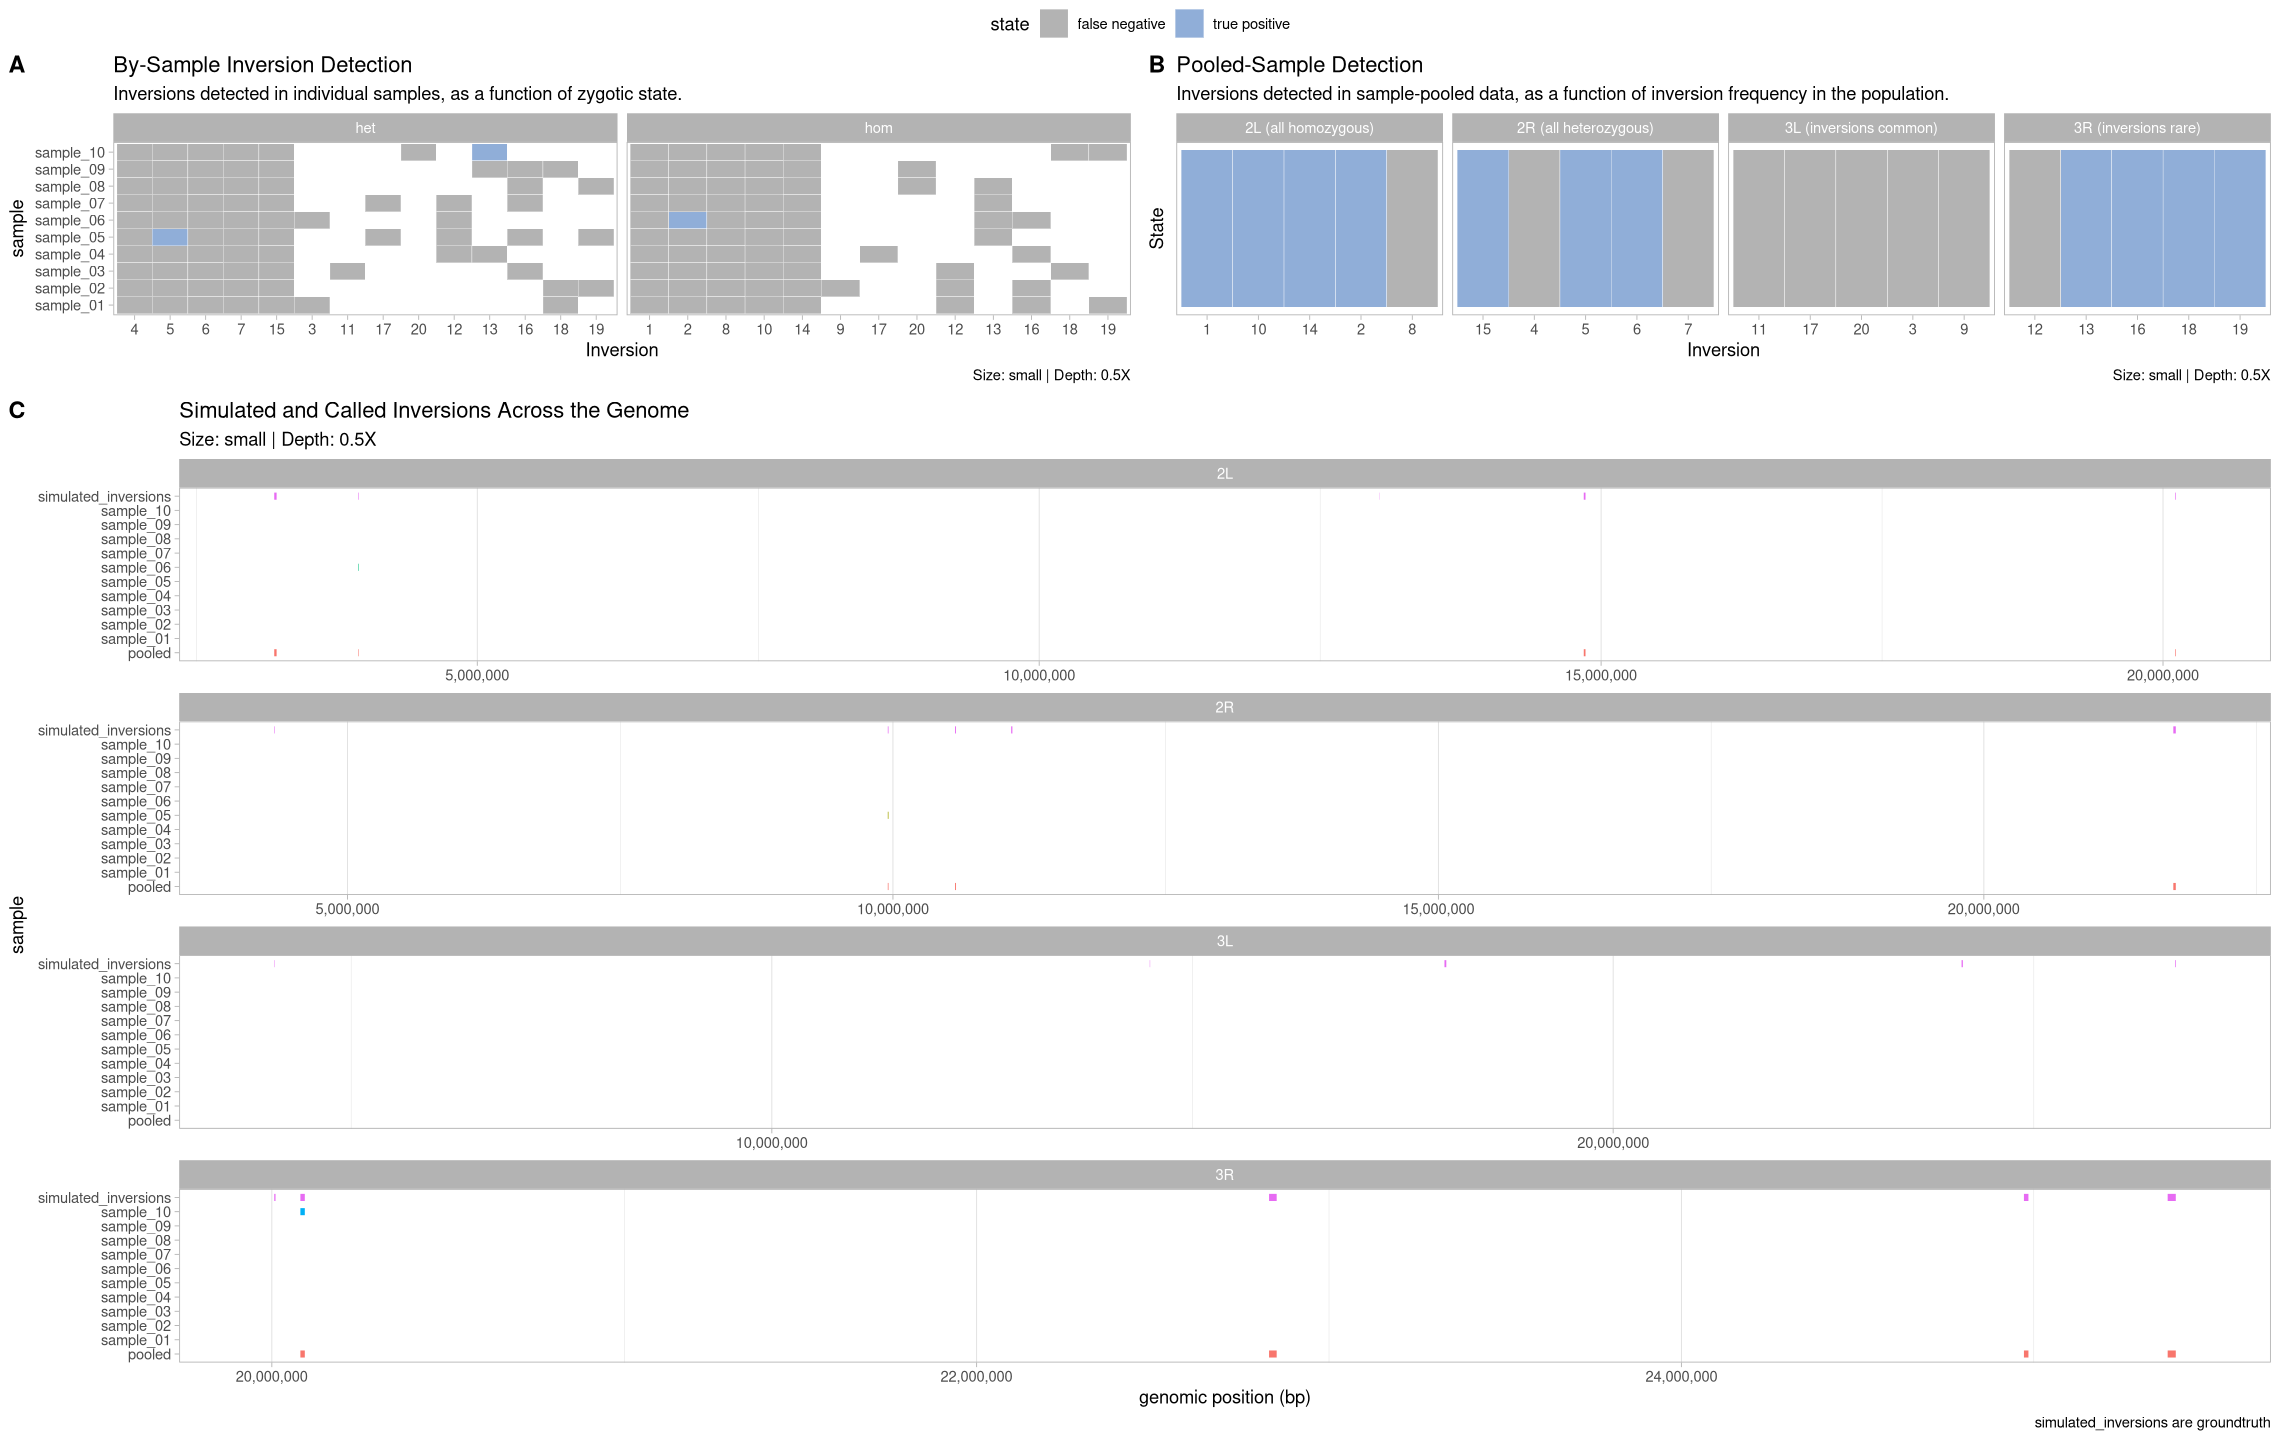

In [121]:
assessment_05X <- summarize_performance(0.5, performance, .size)

## 2X Depth

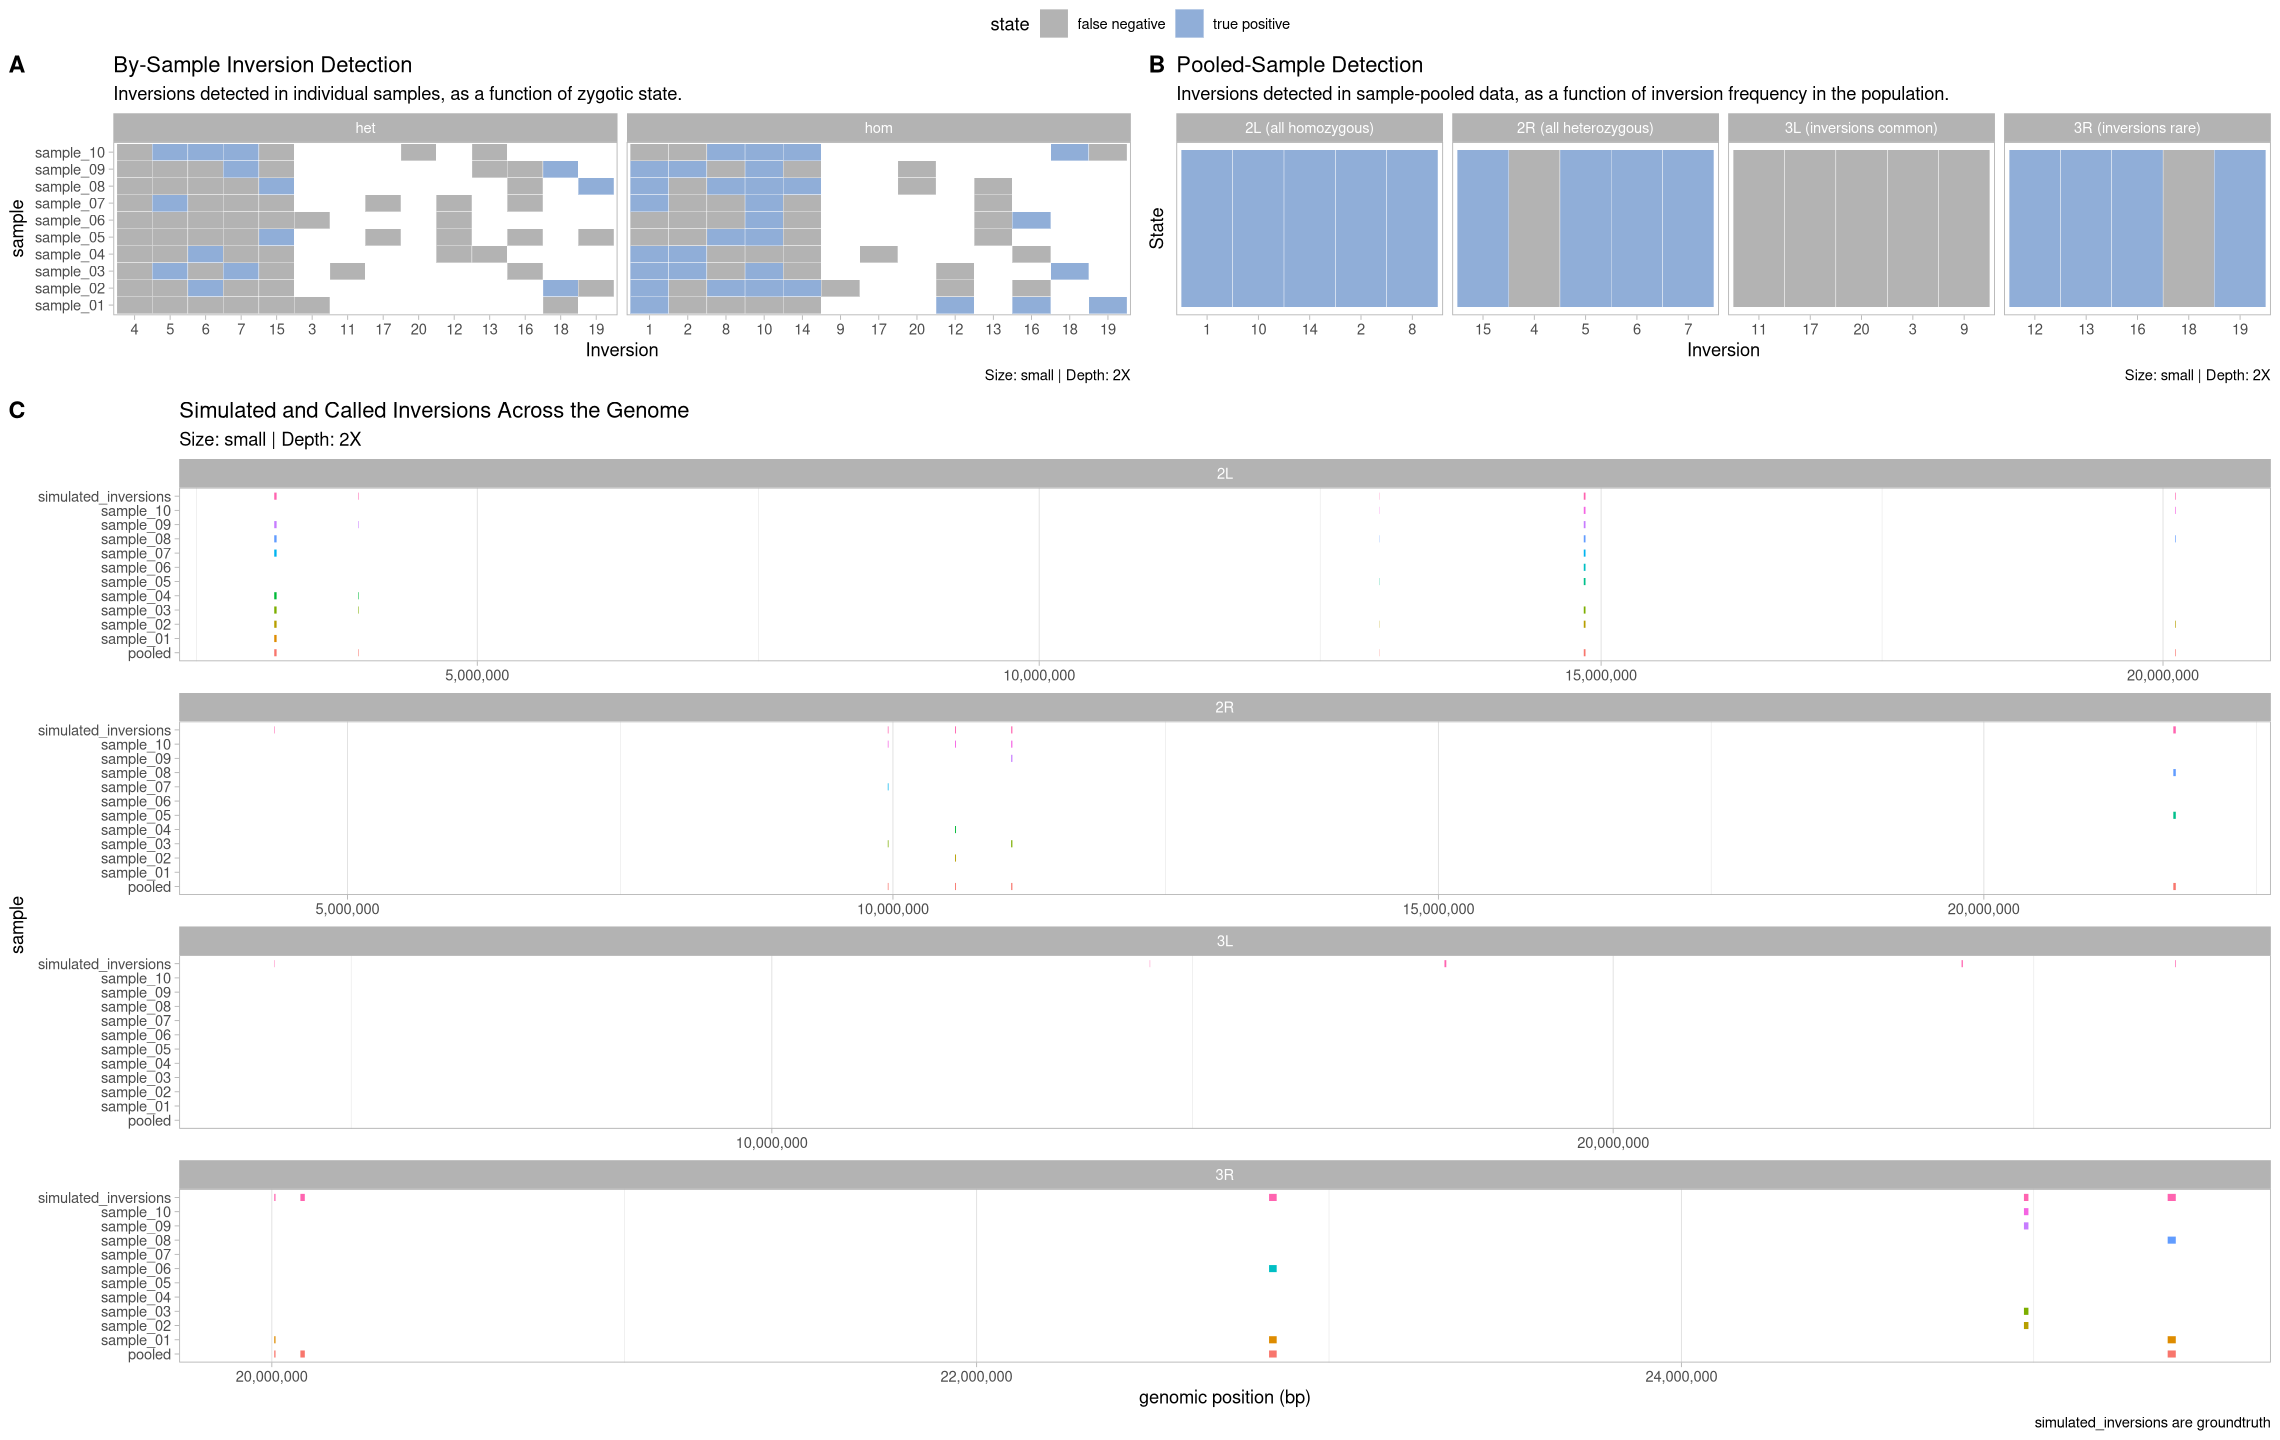

In [122]:
assessment_2X <- summarize_performance(2, performance, .size)

## 5X Depth

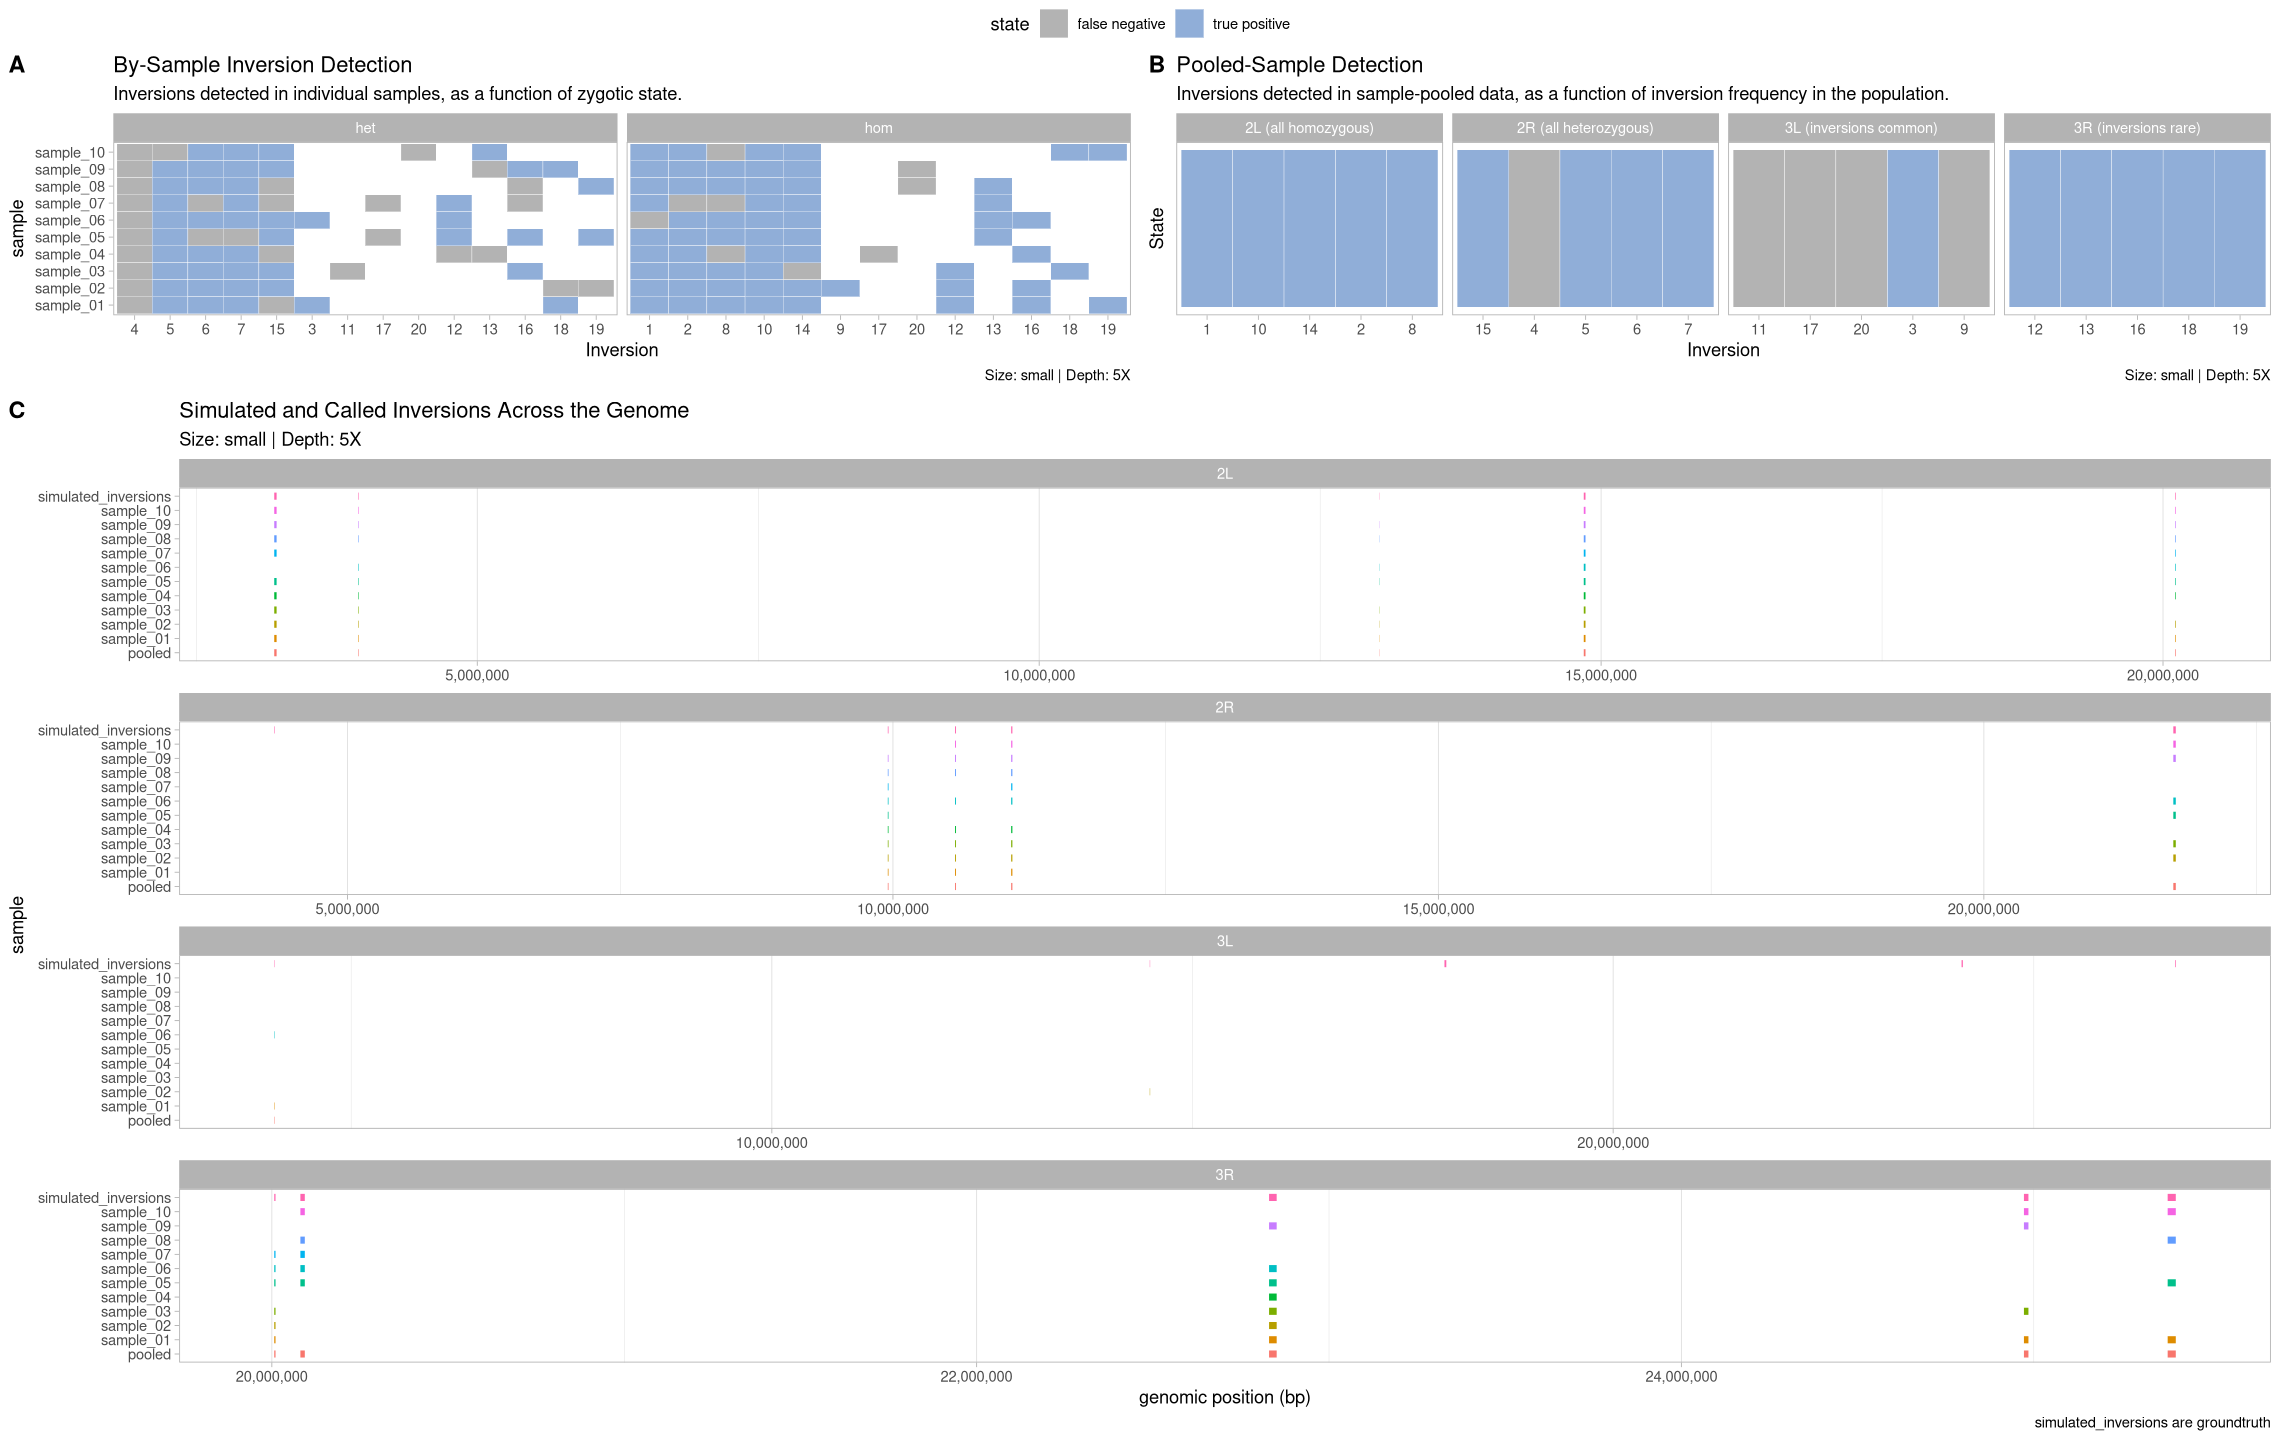

In [123]:
assessment_5X <- summarize_performance(5, performance, .size)

## 10X Depth

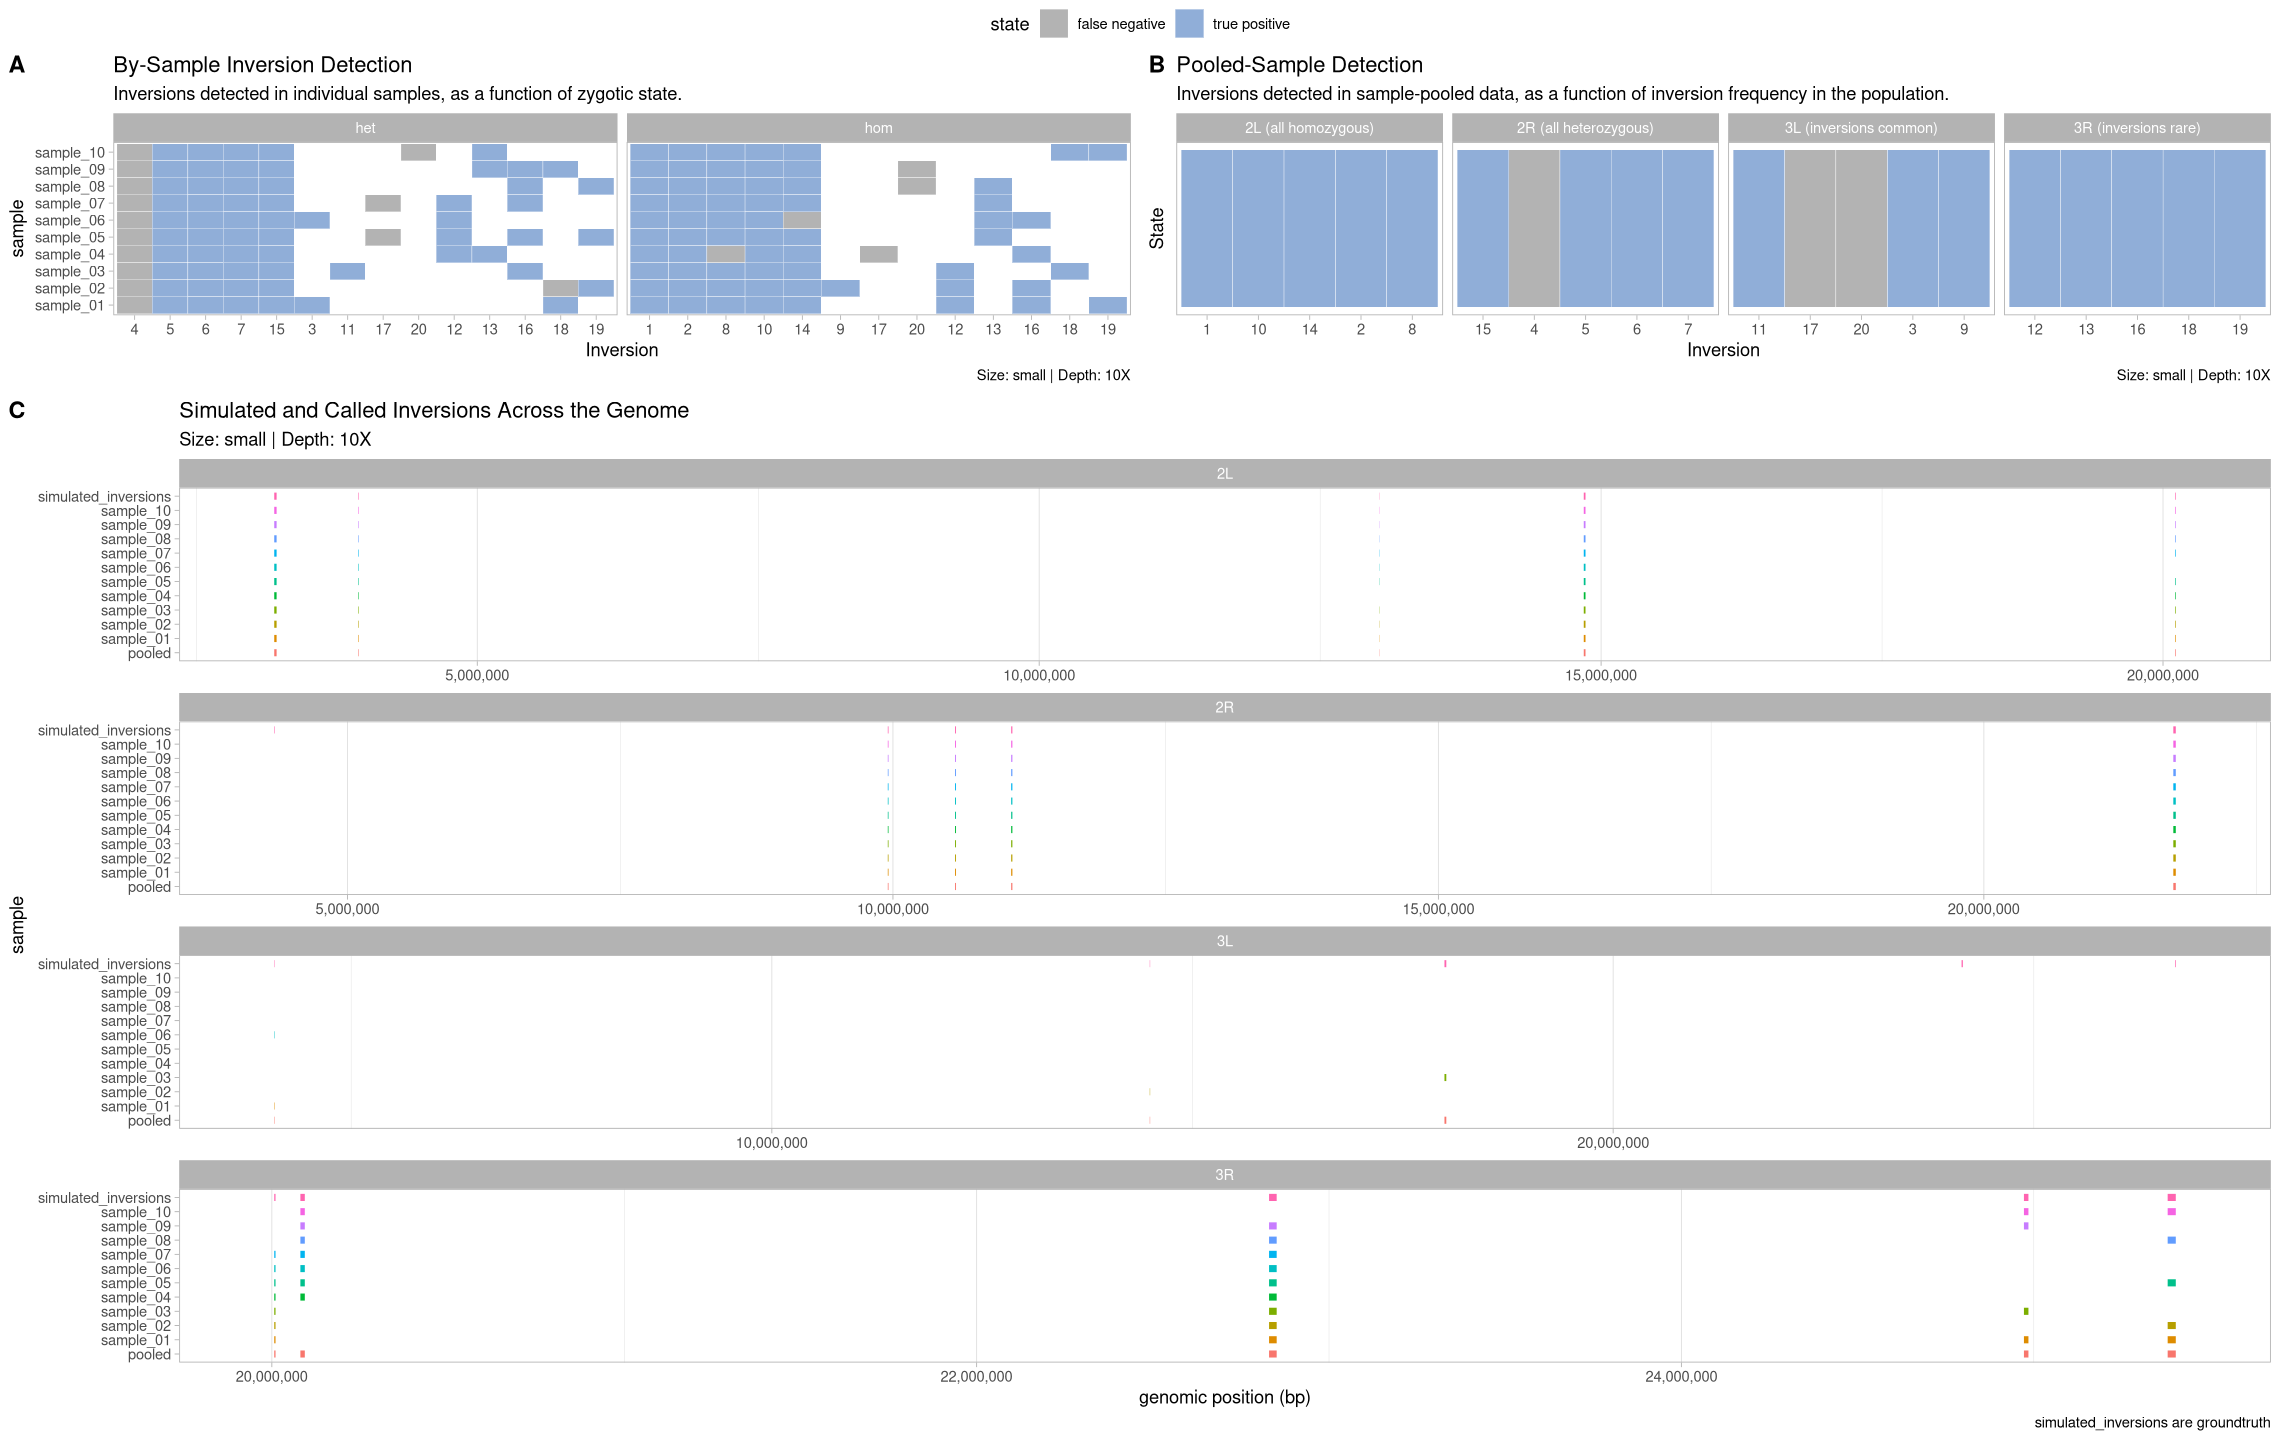

In [124]:
assessment_10X <- summarize_performance(10, performance, .size)

## 20X Depth

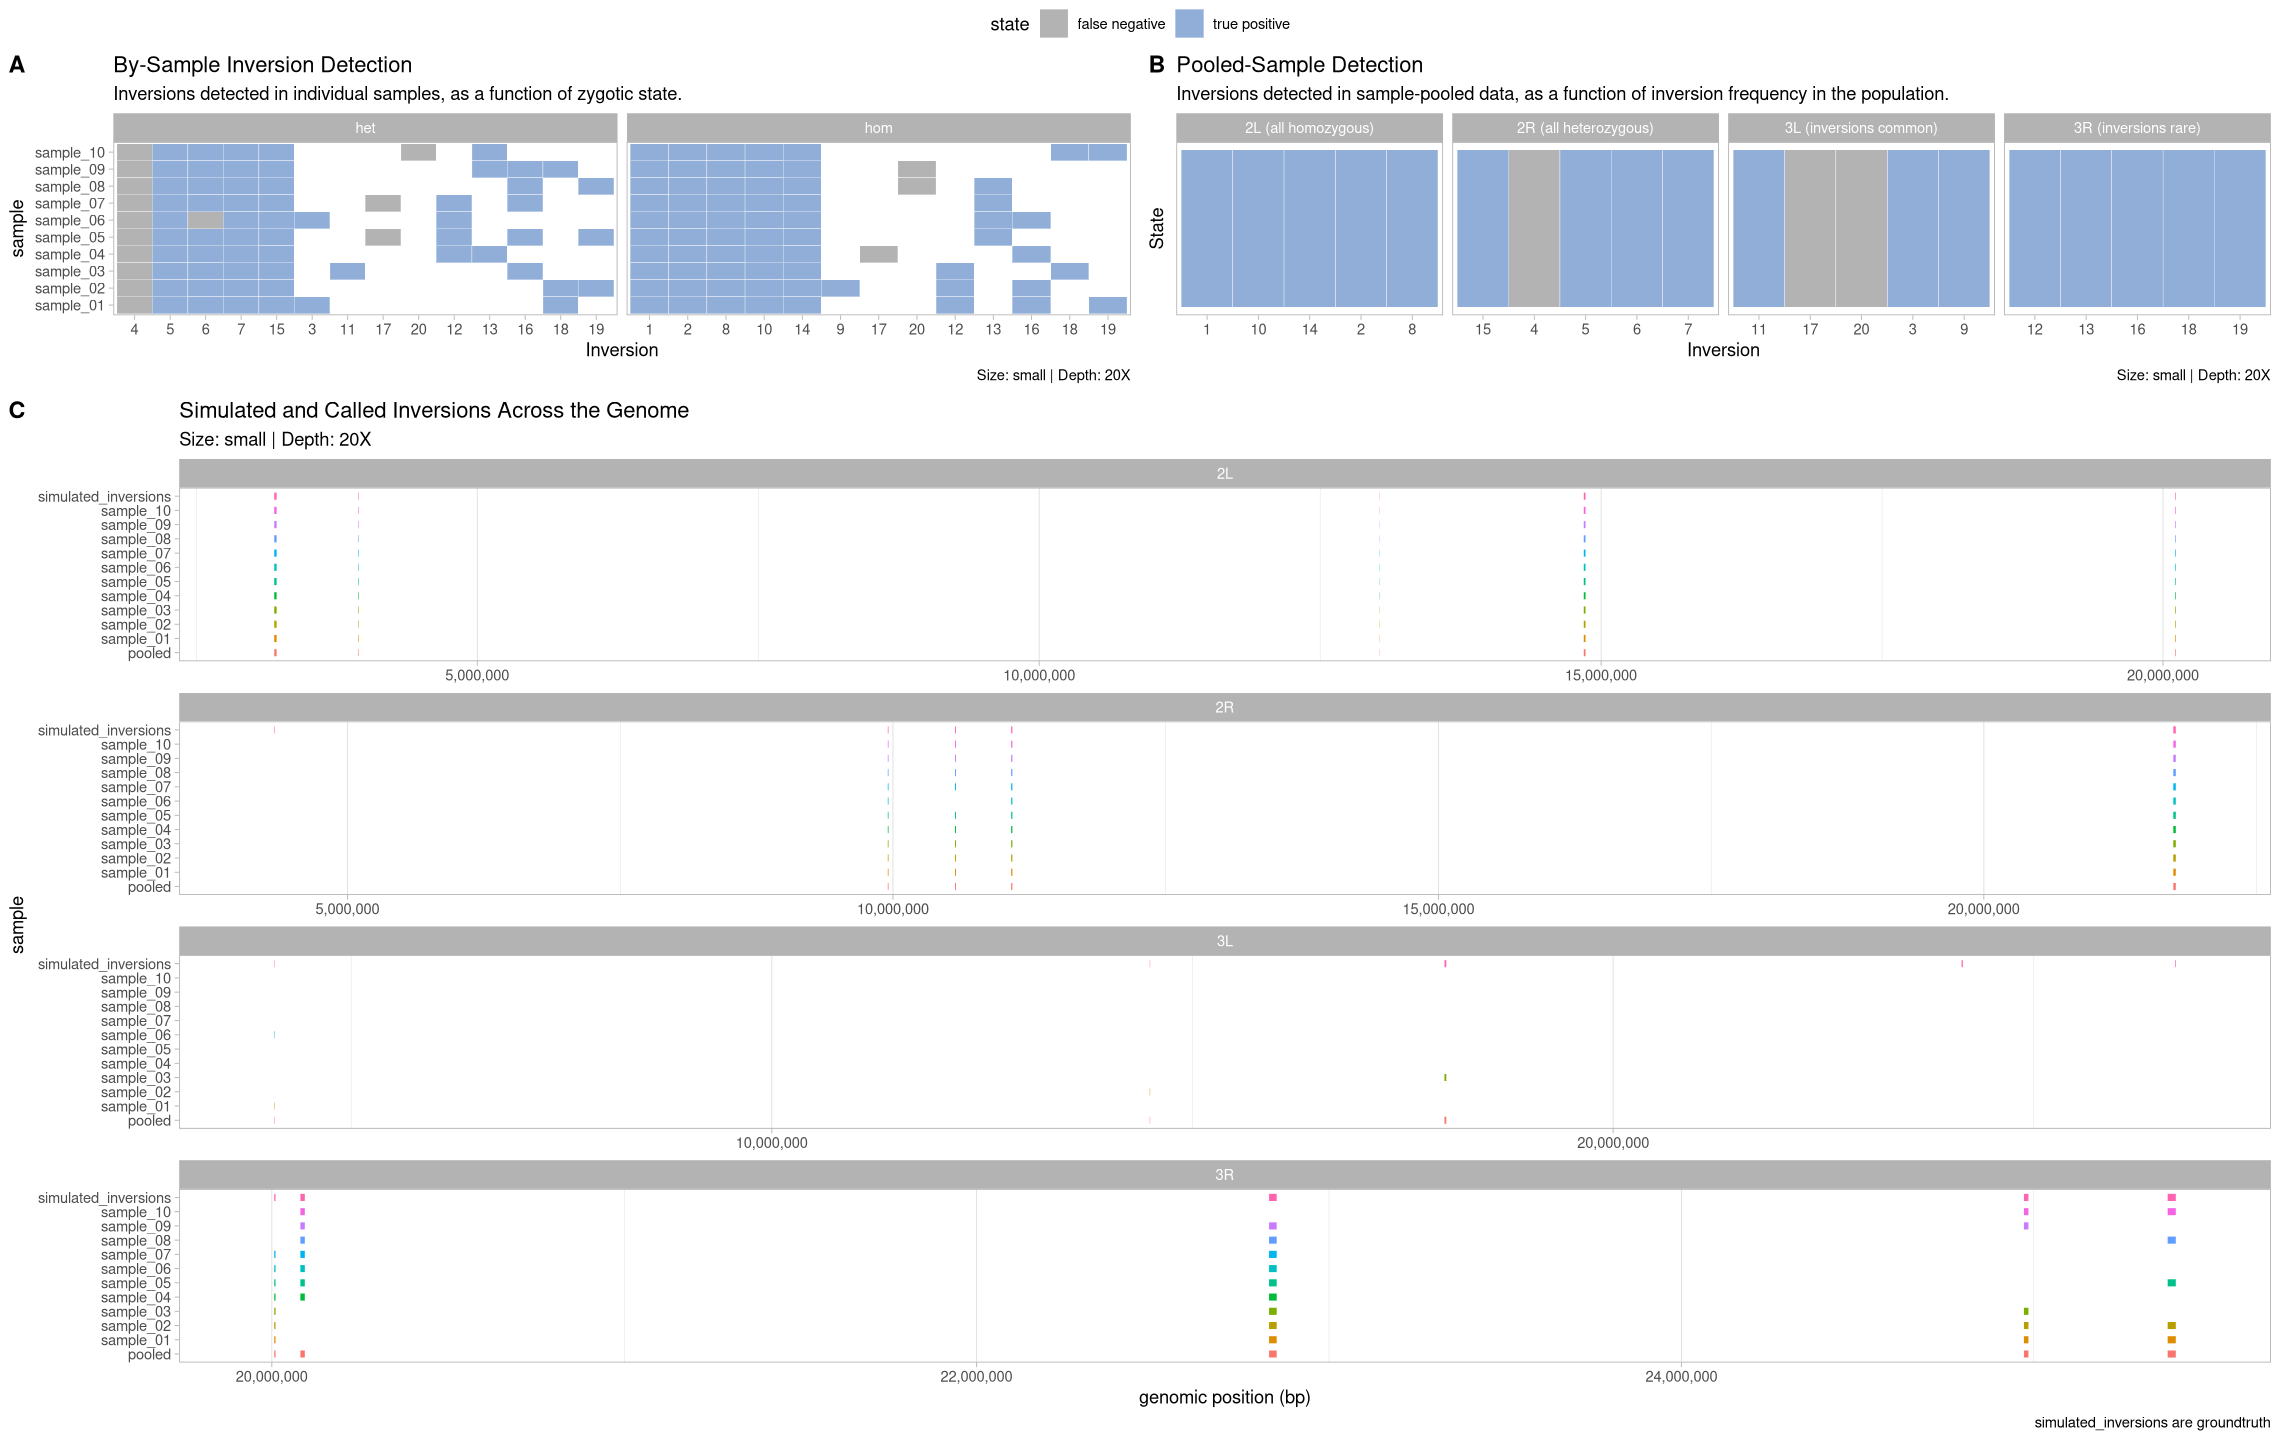

In [125]:
assessment_20X <- summarize_performance(20, performance, .size)

Write the results to a file

In [126]:
.x <- list(assessment_05X, assessment_2X, assessment_5X, assessment_10X, assessment_20X)
depths  <- c(0.5, 2, 5, 10, 20)
aggregate_df <- assessment_05X[0,]
aggregate_df$depth <- character()
for(i in 1:5){
    .tbl <- .x[i][[1]]
    .tbl$depth <- depths[i]
    aggregate_df <- rbind(aggregate_df, .tbl)
}
# sort it to make it visually sensible
aggregate_df <- arrange(aggregate_df, contig,inversion,depth, sample)
# restore contig names
aggregate_df$contig <- gsub("\\s*\\([^\\)]+\\)", "", aggregate_df$contig)
head(aggregate_df)
ifelse(!dir.exists("assess_called_sv"), dir.create("assess_called_sv"), TRUE)
write.csv(aggregate_df, file = paste0("assess_called_sv/",.size, ".sv.assessment"), quote = F, row.names = F)

,contig,inversion,id,position_start,position_end,sample,size,simulated,zygosity,state,depth
,<chr>,<int>,<int>,<int>,<dbl>,<chr>,<chr>,<lgl>,<chr>,<chr>,<dbl>
1,2L,1,1,3193196,3214221,pooled,small,TRUE,hom,true positive,0.5
2,2L,1,1,3193196,3214221,sample_01,small,TRUE,hom,false negative,0.5
3,2L,1,1,3193196,3214221,sample_02,small,TRUE,hom,false negative,0.5
4,2L,1,1,3193196,3214221,sample_03,small,TRUE,hom,false negative,0.5
5,2L,1,1,3193196,3214221,sample_04,small,TRUE,hom,false negative,0.5
6,2L,1,1,3193196,3214221,sample_05,small,TRUE,hom,false negative,0.5


[1] TRUE